# REDES NEURONALES

---



En esta actividad vamos a utilizar una red neuronal para clasificar imágenes de dígitos del 0 al 9 escritos a mano. Para ello, utilizaremos Keras con TensorFlow.

El dataset a utilizar es MNIST, una base de datos constituida por (como no) imágenes de dígitos escritos a mano. Este dataset es ampliamente utilizado en docencia como punto de entrada al entrenamiento de redes neuronales y otros, pero también es muy utilizado en trabajos reales de investigación para el entrenamiento de imágenes. Puedes consultar más información sobre el dataset en [este enlace](https://es.wikipedia.org/wiki/Base_de_datos_MNIST).

El código utilizado para contestar tiene que quedar claramente reflejado en el Notebook. Puedes crear nuevas celdas si así lo deseas para estructurar tu código y sus salidas. A la hora de entregar el notebook, **asegúrate de que los resultados de ejecutar tu código han quedado guardados y que son perfectamente visibles en la versión PDF que debes entregar adjunta**. Por ejemplo, a la hora de entrenar una red neuronal tiene que verse claramente un log de los resultados de cada epoch.

In [1]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import RMSprop, Adam

from keras.datasets.mnist import load_data
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np


Tenemos la suerte de que el dataset MNIST, el que vamos a utilizar en esta actividad, está guardado en Keras, por lo que podemos utilizarlo sin necesidad de buscar el dataset de forma externa.

In [2]:
mnist = tf.keras.datasets.fashion_mnist

Llamar a **load_data** en este dataset nos dará dos conjuntos de dos listas, estos serán los valores de entrenamiento y prueba para los gráficos que contienen los dígitos y sus etiquetas.

Nota: Aunque en esta actividad lo veis de esta forma, también lo vais a poder encontrar como 4 variables de esta forma: training_images, training_labels, test_images, test_labels = mnist.load_data()

In [3]:
(training_images, training_labels), (test_images, test_labels) = load_data()

Antes de continuar vamos a dar un vistazo a nuestro dataset, para ello vamos a ver una imagen de entrenamiento y su etiqueta o clase.

5
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 182 247 241   0 

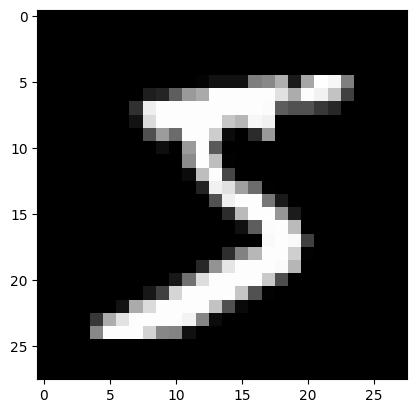

In [4]:
import numpy as np
np.set_printoptions(linewidth=200)
plt.imshow(training_images[0], cmap="gray") # recordad que siempre es preferible trabajar en blanco y negro
#
print(training_labels[0])
print(training_images[0])

## 1. Información sobre el dataset

Una vez tenemos los datos cargados en memoria, vamos a obtener información sobre los mismos.

**Pregunta 1.1 *(0.25 puntos)*** ¿Cuántas imágenes hay de *training* y de *test*? ¿Qué tamaño tienen las imágenes?

In [5]:
### Tu código aquí ###
train_length = training_images.shape[0]
test_length = test_images.shape[0]

print(f'Numero total de imágenes en train: {train_length}')
print(f'Numero total de imágenes en test: {test_length}')

Numero total de imágenes en train: 60000
Numero total de imágenes en test: 10000


In [6]:
print(f"Tamaño de cada imagen: {training_images.shape[1]}x{training_images.shape[2]}")

Tamaño de cada imagen: 28x28


Como se puede apreciar en los fragmentos de código anteriores, el total de imágenes para entrenamiento es de 60000, mientras que para train es 10000.
Las imágenes, como se puede también observar accediendo a las posiciones 1 y 2 del atributo shape del dataset, son 28 x 28 píxeles.

**Pregunta 1.2 *(0.25 puntos)*** Realizar una exploración de las variables que contienen los datos. Describir en qué consiste un example del dataset (qué información se guarda en cada imagen) y describir qué contiene la información en y.

In [7]:
### Tu código aquí ###

print('Shape de training_images:', training_images.shape)
print('Shape de training_labels:', training_labels.shape)
print('Shape de test_images:', test_images.shape)
print('Shape de test_labels:', test_labels.shape)

Shape de training_images: (60000, 28, 28)
Shape de training_labels: (60000,)
Shape de test_images: (10000, 28, 28)
Shape de test_labels: (10000,)


In [8]:
unique, counts = np.unique(training_labels, return_counts=True)
print('\nDistribución de clases en train:')
for label, count in zip(unique, counts):
    print(f'Numero {label}: {count} imagenes')


Distribución de clases en train:
Numero 0: 5923 imagenes
Numero 1: 6742 imagenes
Numero 2: 5958 imagenes
Numero 3: 6131 imagenes
Numero 4: 5842 imagenes
Numero 5: 5421 imagenes
Numero 6: 5918 imagenes
Numero 7: 6265 imagenes
Numero 8: 5851 imagenes
Numero 9: 5949 imagenes



Ejemplo de la primera imagen del dataset de entrenamiento:
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   

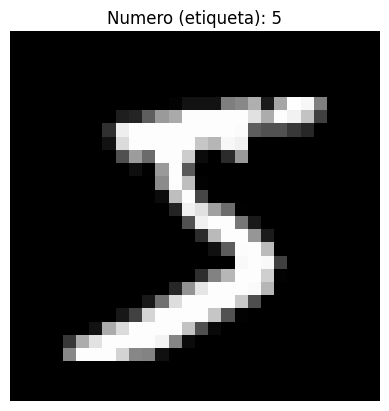

In [9]:
print('\nEjemplo de la primera imagen del dataset de entrenamiento:')
print(training_images[0])
print(f'Número asignado (etiqueta): {training_labels[0]}')

plt.imshow(training_images[0], cmap='gray')
plt.title(f'Numero (etiqueta): {training_labels[0]}')
plt.axis('off')
plt.show()

En el primer fragmento de código se puede observar la forma de las variables que contienen los datos. Hay 4:


1. training_images: se refiere a las imágenes de entrenamiento. Como se vio anteriormente, hay 60000, que es el primer valor, y los dos siguientes, 28x28, se refiere a las dimensiones de cada una de ellas.
2. training_labels: contiene las etiquetas asignadas a cada una de las imagenes. El tamño total, que es el valor que se muestra, es de 60000, al igual que el tamño de la muestra.
3. test_images: se refiere a las imagenes del conjunto de test. Hay 10000, con dimensiones también de 28x28
4. teste_labels: las etiquetas asignadas a llas imágenes de test.

Posteriormente, se ha hecho un pequeño análisis para observar la distribución por clases y ver si hay alguna desbalanceada. A priori parece que no, lo cual es una buena señal para poder realizar un buen entrenamiento del modelo.

Por últimom, se ha mostrado una imagen, la primera del conjunto de entrenamiento. Cada imagen consiste en una matriz de 28 x 28 valores (su dimensión). Cada valor dentro de la matriz refleja el valor del pixel en escala de grises, donde 0 es el negro absoluto y 255 el blanco. En este caso, como la etiqueta asignada es un 5, se puede observar como los valores de los pixeles mayores que 0 forman una figura similar a este número. Para confirmarlo, también se ha imprimido la imagen con la librería matplotlib, que ofrece una representación mucho más visual.

## 2. Normalización y preprocesado de los datos

**Pregunta 2.1 (0.25 puntos)** Habreis notado que todos los valores numericos están entre 0 y 255. Si estamos entrenando una red neuronal, una buena practica es transformar todos los valores entre 0 y 1, un proceso llamado "normalización" y afortunadamente en Python es fácil normalizar una lista. ¿Cómo lo podemos hacer?

In [10]:
### Tu código aquí ###

norm_training_images = training_images / 255.0
norm_test_images = test_images / 255.0

Normalizar los datos es una buena práctica para mejorar la convergencia y la estabilidad del entrenamiento. En este caso, como los valores de los pixeles están en el rango 0, 255, y para tenerlos normalizados se quieren en el rango [0, 1], únicamente es necesario dividir los pixeles de todas las imágenes entre 255.0

**Pregunta 2.2 (0.25 puntos)** Utiliza la función ***reshape*** de Numpy para convertir las imágenes en vectores de características de un tamaño de (N, 784). Explica con tus palabras por qué es necesario hacer esto.



In [11]:
### Tu código aquí ###

X_train = norm_training_images.reshape((-1, 784))
X_test = norm_test_images.reshape((-1, 784))

La entrada de una red nueronal densa debe ser un único vector, no imagenes en 2 dimensiones. Para solventar este problema, se deben convertir las imágenes 2D en vectores de 1D. El hecho de que el segundo argumento de reshape sea 784 es porque las imágenes son de 28x28=784 píxeles cada una.Este proceso permite que cada pixel sea procesado por la red de manera independiente.

**Respuesta a la pregunta 2.2**:

**Pregunta 2.3 (0.25 puntos)** Para facilitar el desarrollo de la actividad, vamos a expresar las etiquetas así:

In [12]:
training_labels = tf.keras.utils.to_categorical(training_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

Muestra cómo son ahora los datos, como resultado de este cambio y también de los realizados en las dos preguntas anteriores. Debate cómo se beneficiará la red neuronal de todos estos cambios.

In [14]:
### Tu código aquí ###

print("Forma de las imágenes de entrenamiento:", X_train.shape)
print("Forma de las imágenes de test:", X_test.shape)

print("Ejemplo de un vector de imagen:")
print(X_train[0])

print("\nForma de las etiquetas de entrenamiento:", training_labels.shape)
print("Ejemplo de una etiquet:")
print(training_labels[0])


Forma de las imágenes de entrenamiento: (60000, 784)
Forma de las imágenes de test: (10000, 784)
Ejemplo de un vector de imagen:
[0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.         0.         0.         0.         0.     

Respuesta a la pregunta 2.3:
Se han hecho tres grandes cambios de los que la red se va a beneficiar.
1. Normalizacion, para que los pixeles situen sus valores entre 0 y 1 y sea mas sencillo entrenarla. Ademas valores muy altos pueden dar problemas en funciones de activacion como la relu.
2. Aplanamiento (reshape): las redes neuronales fully connected no entienden matrices, y es necesario realizar esta operacion para que las imágenes puedan servir de entrada.
3. Enconding de etiquetas: esta última operación convierte las etiquetas en categóricas. En este caso, transforma los números enteros del 0 al 9 que representan las clases en vetores binarios que indican la clase. Esto es preciso para que la función de pérdida categorical_crossentropy se calcule correctamente.

## 3. Creación del Modelo

Ahora vamos a definir el modelo, pero antes vamos a repasar algunos comandos y conceptos muy útiles:
* **Sequential**: Eso define una SECUENCIA de capas en la red neuronal
* **Dense**: Añade una capa de neuronas
* **Flatten**: ¿Recuerdas cómo eran las imágenes cuando las imprimiste para poder verlas? Un cuadrado, Flatten toma ese cuadrado y lo convierte en un vector de una dimensión.

Cada capa de neuronas necesita una función de activación. Normalmente se usa la función relu en las capas intermedias y softmax en la ultima capa (en problemas de clasificación de más de dos items)
* **Relu** significa que "Si X>0 devuelve X, si no, devuelve 0", así que lo que hace es pasar sólo valores 0 o mayores a la siguiente capa de la red.
* **Softmax** toma un conjunto de valores, y escoge el más grande.

 **Pregunta 3.1 (0.5 puntos)**. Utilizando Keras, y preparando los datos de X e Y como fuera necesario, define y entrena una red neuronal que sea capaz de clasificar imágenes de MNIST con las siguientes características:

* Una capa de entrada del tamaño adecuado.
* Una capa oculta de 512 neuronas.
* Una capa final con 10 salidas.

In [15]:
### Tu código para la red neuronal de la pregunta 3 aquí ###

model = Sequential()
model.add(Dense(512, activation='relu', input_shape=(784,)))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Se ha elegido relu por su capacidad para aprender representaciones no lineales y por su eficiencia computacional frente a otras funciones de activación.
Por su parte, softmax es muy útil para clasificación multiclase. El hecho de añadir 10 salidas es porque hay 10 clases y debe haber una neurona por cada clase diferente.

NOTA: he sacado una interpretación doble del enunciado. Esto es una aclaración. Con la primera instrucción add entiendo que se crean tanto la capa de entrada como la capa oculta, ya que keras automáticamente entiende que al indicar input_shape se está refiriendo a la capa de entrada. No estoy al 100% seguro de que no habría que agregar otra capa densa, pero por lo que he visto la primera intrucción add crearía las dos capas. https://www.aprendemachinelearning.com/una-sencilla-red-neuronal-en-python-con-keras-y-tensorflow/

**Pregunta 3.2 (0.25 puntos)**: ¿crees conveniente utilizar una capa flatten en este caso? Motiva tu respuesta.



Sí y no. Al tratarse de imágenes sí es necesario añadir una capa flatten para convertir estas imágenes en 2D en vectores de 1D. Sin embargo, en etapas anteriores de este notebook se ha hecho un reshape para que las imágenes ya estén en este formato vectorial, por lo que no es necesario realizar esta transformación nuevamente.
Si no se hiciese este reshape en la etapa de preparación, sí que sería necesario añadir la capa flatten.

In [ ]:
### Tu código para incluir una capa flatten si lo ves necesario ###

**Respuesta a la pregunta 3.2**:

**Pregunta 3.3 (0.25 puntos)**: Utiliza la función summary() para mostrar la estructura de tu modelo.

In [15]:
### Tu código aquí ###

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

El número de parámetros de la primera capa (401920) se obtiene realizando 512 * 784 + 512. Esto es porque hay un param por cada capa y elemento de entrada a lo que hay que sumaar un bias por cada neurona.

## 4: Compilación y entrenamiento

**Pregunta 4.1 (0.5 puntos)**: Compila tu modelo. Utiliza ***categorical_crossentropy*** como función de pérdida, ***Adam*** como optimizador, y monitoriza la ***tasa de acierto*** durante el entrenamiento. Explica qué hace cada cosa en la compilación.

In [16]:
### Tu código aquí ###

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

1. categorical_crossentropy suele ser la función de pérdida asociada a softmax para problemas de clasificación multiclase. Además, las etiquetas están en formato vectorial, para lo que está preparada. Penaliza más aquellas predicciones que se alejan del valor esperado
2. adam es un optimizador que ajusta automáticamente el leanring rato de cada parámetro durante del entrenamiento.
3. la métrica accuracy calcula el porcentaje de predicciones que fueron correctas.

**Respuesta a la pregunta 4.1**:

**Pregunta 4.2 (0.5 puntos)**: Utiliza la función ***fit()*** para entrenar tu modelo. Para ayudarte en tu primer entrenamiento, utiliza estos valores:
*   epochs = 5
*   batch_size = 32
*   validation_split = 0.25



In [17]:
### Tu código aquí ###

history = model.fit(
    X_train, training_labels,
    epochs=5,
    batch_size=32,
    validation_split=0.25
)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8904 - loss: 0.3811 - val_accuracy: 0.9629 - val_loss: 0.1249
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9731 - loss: 0.0937 - val_accuracy: 0.9676 - val_loss: 0.1093
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - accuracy: 0.9827 - loss: 0.0558 - val_accuracy: 0.9651 - val_loss: 0.1154
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 34s 11ms/step - accuracy: 0.9875 - loss: 0.0412 - val_accuracy: 0.9747 - val_loss: 0.0856
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9918 - loss: 0.0278 - val_accuracy: 0.9742 - val_loss: 0.0916


Este modelo utiliza los datos de entrenamiento. El dataset recorre de manera completa 5 veces la red neuronal. 32 es el número de instancias que el modelo procesa antes de actualizar los pesos. Por último, utiliza el 25% de los datos de entrenamiuento como conjutno de validación, que ayuda a detectar overfitting.

# 5: Impacto al variar el número de neuronas en las capas ocultas

En este ejercicio vamos a experimentar con nuestra red neuronal cambiando el numero de neuronas por 512 y por otros valores. Para ello, utiliza la red neuronal de la pregunta 3, y su capa oculta cambia el número de neuronas:

* **216 neuronas en la capa oculta
* **1024 neuronas en la capa oculta

y entrena la red en ambos casos.



In [18]:
### Tu código para 216 neuronas aquí ###

model_216 = Sequential()
model_216.add(Dense(216, activation='relu', input_shape=(784,)))
model_216.add(Dense(10, activation='softmax'))

model_216.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

history_216 = model_216.fit(
    X_train, training_labels,
    epochs=5,
    batch_size=32,
    validation_split=0.25
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8763 - loss: 0.4382 - val_accuracy: 0.9584 - val_loss: 0.1434
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9670 - loss: 0.1150 - val_accuracy: 0.9652 - val_loss: 0.1144
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9776 - loss: 0.0754 - val_accuracy: 0.9725 - val_loss: 0.0920
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9845 - loss: 0.0527 - val_accuracy: 0.9715 - val_loss: 0.0950
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9893 - loss: 0.0369 - val_accuracy: 0.9729 - val_loss: 0.0915


In [19]:
### Tu código para 1024 neuronas aquí ###

model_1024 = Sequential()
model_1024.add(Dense(1024, activation='relu', input_shape=(784,)))
model_1024.add(Dense(10, activation='softmax'))

model_1024.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

history_1024 = model_1024.fit(
    X_train, training_labels,
    epochs=5,
    batch_size=32,
    validation_split=0.25
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.8920 - loss: 0.3520 - val_accuracy: 0.9664 - val_loss: 0.1149
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 39s 17ms/step - accuracy: 0.9750 - loss: 0.0804 - val_accuracy: 0.9720 - val_loss: 0.0904
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.9846 - loss: 0.0508 - val_accuracy: 0.9711 - val_loss: 0.1041
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 39s 18ms/step - accuracy: 0.9891 - loss: 0.0342 - val_accuracy: 0.9731 - val_loss: 0.0970
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - accuracy: 0.9920 - loss: 0.0244 - val_accuracy: 0.9745 - val_loss: 0.0968


**Pregunta 5.1 (0.5 puntos)**: ¿Cual es el impacto que tiene la red neuronal?

Respuesta a la pregunta 5.1:
Fijándose en el resultado de val_accuracy los tres modelos presentan un valor mayor a 0.97, lo cual es muy alto. El modelo de 216 presenta 0.9729, mientras que el de 512 aumenta hasta 0.9757. Sin embaargo, al aumentar a 1024 el resultado es ligeramente menor, 0.9745, además de qye el tiempo de ejecución es mucho más alto. Podría estar presentando overfitting.
El coste computacional aumenta mucho en proporción desde 512 a 1024 y reduce el beneficio. El de 512 sí que aumenta con respoecto a 216 y también disminuye el val_loss.
Pese a que los tres modelos dan resultados muy similares, el de 512 sería el mejor en términos de eficiencia - eficacia.

# 6: Número de neuronas de la capa de salida
Considerad la capa final, la de salida de la red neuronal de la pregunta 3.

**Pregunta 6.1 (0.25 puntos)**: ¿Por qué son 10 las neuronas de la última capa?

**Pregunta 6.2 (0.25 puntos)**: ¿Qué pasaría si tuvieras una cantidad diferente a 10?

Por ejemplo, intenta entrenar la red con 5, para ello utiliza la red neuronal de la pregunta 1 y cambia a 5 el número de neuronas en la última capa.

In [21]:
### Tu código de la red neuronal con 5 neuronas en la capa de salida de la pregunta 6 aquí ###

model_5salida = Sequential()
model_5salida.add(Dense(512, activation='relu', input_shape=(784,)))
model_5salida.add(Dense(5, activation='softmax'))

model_5salida.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

history_5salida = model_5salida.fit(
    X_train, training_labels,
    epochs=5,
    batch_size=32,
    validation_split=0.25
)

Epoch 1/5


ValueError: Arguments `target` and `output` must have the same shape. Received: target.shape=(None, 10), output.shape=(None, 12)

Tu respuestas a la pregunta 6.1 aquí:
Como se dijo anteriormente, la capa de salida tiene 10 neuronas porque en este problema de clasificacion multiclase hay 10 clases posible (números del 1 al 9). Cada neurona representa la probabilidad de que la imagen de entrada corresponda a cada una de las clases.

Tu respuestas a la pregunta 6.2 aquí:
Si se usan menos de 10 neuronas da error, ya que el modelo no es capaz de realizar una predicción para cada una de las clases. Se puede ver en el output del fragmento de código anteriror que el error proviene de utilizar un número diferente en target y output.
También se ha probado el bloque con 12 neuronas de salida, para ver si cambiaba poniendo más en vez de menos, pero el resultado es exactamente el mismo, que el número de neuronas de salida y el número de clases debe ser igual.

# 7: Aumento de epoch y su efecto en la red neuronal
En este ejercicio vamos a ver el impacto de aumentar los epoch en el entrenamiento. Usando la red neuronal de la pregunta 3:

**Pregunta 7.1 (0.25 puntos)**
* Intentad 15 epoch para su entrenamiento, probablemente obtendras un modelo con una pérdida mucho mejor que el que tiene 5.

**Pregunta 7.2 (0.25 puntos)**
* Intenta ahora con 30 epoch para su entrenamiento.

**Pregunta 7.3 (0.25 puntos)**
* ¿Qué está pasando en la pregunta anterior? Explica tu respuesta y da el nombre de este efecto si lo conoces.

In [18]:
### Tu código para 15 epoch aquí ###
#Nota: el entrenamiento de estos modelos es muy largo, y se han hecho varias iteraciones para probar cosas
# con el objetivo de agilizar esto, para estos dos modelos se ha utilizado 216 neuronas en la capa oculta

model_15epochs = Sequential()
model_15epochs.add(Dense(216, activation='relu', input_shape=(784,)))
model_15epochs.add(Dense(10, activation='softmax'))

model_15epochs.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

history_15_epochs = model_15epochs.fit(X_train, training_labels,
                              epochs=15,
                              batch_size=32,
                              validation_split=0.25,
                              verbose=1)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8695 - loss: 0.4441 - val_accuracy: 0.9573 - val_loss: 0.1475
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9667 - loss: 0.1140 - val_accuracy: 0.9625 - val_loss: 0.1243
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9782 - loss: 0.0759 - val_accuracy: 0.9687 - val_loss: 0.1010
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9855 - loss: 0.0502 - val_accuracy: 0.9692 - val_loss: 0.1072
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9886 - loss: 0.0381 - val_accuracy: 0.9732 - val_loss: 0.0914
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9919 - loss: 0.0266 - val_accuracy: 0.9739 - val_loss: 0.0904
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9945 - loss: 0.0201 - val_accuracy: 0.9726 - val_loss: 0.0989
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9948 - loss: 0.01

In [19]:
### Tu código para 30 epoch aquí ###

model_30epochs = Sequential()
model_30epochs.add(Dense(216, activation='relu', input_shape=(784,)))
model_30epochs.add(Dense(10, activation='softmax'))

model_30epochs.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

history_30_epochs = model_30epochs.fit(X_train, training_labels,
                              epochs=30,
                              batch_size=32,
                              validation_split=0.25,
                              verbose=1)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8755 - loss: 0.4371 - val_accuracy: 0.9527 - val_loss: 0.1598
Epoch 2/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9641 - loss: 0.1210 - val_accuracy: 0.9650 - val_loss: 0.1152
Epoch 3/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9777 - loss: 0.0744 - val_accuracy: 0.9694 - val_loss: 0.1043
Epoch 4/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9835 - loss: 0.0557 - val_accuracy: 0.9706 - val_loss: 0.0977
Epoch 5/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9896 - loss: 0.0373 - val_accuracy: 0.9717 - val_loss: 0.0995
Epoch 6/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9898 - loss: 0.0332 - val_accuracy: 0.9719 - val_loss: 0.0992
Epoch 7/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9933 - loss: 0.0214 - val_accuracy: 0.9721 - val_loss: 0.1038
Epoch 8/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9943 - loss: 0.

Tu respuesta a la pregunta 7.3 aquí:
A medida que aumenta el número de época, el valor de accuracy para los datos de entrenamiento va aumentando mucho. Sin embargo, esto significa que está aprendiendo demasiado de estos datos. Al observar la accuracy de validación, se puede observar que incluso con el paso de las epochs el valor va bajando y va aumentando el valor de su pérdida. A este fenómeno se le denomina overfitting o sobreajuste. Se puede observar mejor en la función de pérdidas, que aumenta drásticamente. Esto se da porque el modelo cada vez hace predicciones más extremas sobre la clase en concreto de las que falla. Es un claro caso de overfitting

Además de lo anterior, y esto se ve bien en el modelo de 15, llega una época en la que el modelo ya no mejora, e itera 'para nada' porque se mantiene más o menos en el mismo resultado para los datos de validación.

# 8: Early stop
En el ejercicio anterior, cuando entrenabas con epoch extras, tenías un problema en el que tu pérdida podía cambiar. Puede que te haya llevado un poco de tiempo esperar a que el entrenamiento lo hiciera,  y puede que hayas pensado "¿no estaría bien si pudiera parar el entrenamiento cuando alcance un valor deseado?", es decir, una precisión del 85% podría ser suficiente para ti, y si alcanzas eso después de 3 epoch, ¿por qué sentarte a esperar a que termine muchas más épocas? Como cualquier otro programa existen formas de parar la ejecución

A partir del código de ejemplo, hacer una nueva función que tenga en cuenta la perdida (loss) y que pueda parar el código para evitar que ocurra el efeto secundario que vimos en el ejercicio 5.

In [20]:
### Ejemplo de código

class myCallback(tf.keras.callbacks.Callback):
      def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy')> 0.85):
              print("\nAlcanzado el 85% de precisión, se cancela el entrenamiento!!")
              self.model.stop_training = True

model_30epochs_2 = Sequential()
model_30epochs_2.add(Dense(512, activation='relu', input_shape=(784,)))
model_30epochs_2.add(Dense(10, activation='softmax'))

model_30epochs_2.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

history_30_epochs_2 = model_30epochs_2.fit(X_train, training_labels,
                              epochs=30,
                              batch_size=32,
                              validation_split=0.25,
                              callbacks=[myCallback()]
                              )

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8844 - loss: 0.3910
Alcanzado el 85% de precisión, se cancela el entrenamiento!!
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.8844 - loss: 0.3908 - val_accuracy: 0.9615 - val_loss: 0.1286


**Pregunta 8.1. *(0.75 puntos)***: Consulta la documentación de Keras y aprende cómo podemos utilizar Early stop en nuestro modelos.

Según la documentación de keras (https://keras.io/api/callbacks/early_stopping/) se puede realizar empleando lo que se conoce como callback con varios parámetros que ajustar. En el código siguiente se explica cada uno de ellos.

In [21]:
### Tu código aquí ###

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',          # es la metrica que se vigila su evolución
    patience=3,                  # es el numero de epochs que no mejore la metrica hasta que para
    restore_best_weights=True   # restaura los pesos a los mejroes ak final del entrenamiento
)

model_stop = Sequential()
model_stop.add(Dense(512, activation='relu', input_shape=(784,)))
model_stop.add(Dense(10, activation='softmax'))

model_stop.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

history_modelstop = model_stop.fit(X_train, training_labels,
                              epochs=30,
                              batch_size=32,
                              validation_split=0.25,
                              callbacks=[early_stop])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8887 - loss: 0.3827 - val_accuracy: 0.9606 - val_loss: 0.1310
Epoch 2/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.9729 - loss: 0.0910 - val_accuracy: 0.9693 - val_loss: 0.1024
Epoch 3/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9831 - loss: 0.0566 - val_accuracy: 0.9717 - val_loss: 0.0977
Epoch 4/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9895 - loss: 0.0360 - val_accuracy: 0.9757 - val_loss: 0.0906
Epoch 5/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9904 - loss: 0.0288 - val_accuracy: 0.9741 - val_loss: 0.0880
Epoch 6/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.9941 - loss: 0.0194 - val_accuracy: 0.9759 - val_loss: 0.0888
Epoch 7/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9954 - loss: 0.0132 - val_accuracy: 0.9754 - val_loss: 0.0982
Epoch 8/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9953 -

Se ha creado un early stop que emplea una técnica en la que si el val_loss no mejora en tres epochs, el modelo para. Esto se usa para que cuando ya tienda a empeorar el val loss o a quedarse igual, no siga entrenando 'para nada'. Se observa como en la iteración 8 el val_loss ya llevaba 3 epochs sin mejorar, por lo que ha parado el entrenamiento

## 9. Unidades de activación

En este ejercicio, vamos a evaluar la importancia de utilizar las unidades de activación adecuadas. Como hemos visto en clase, funciones de activación como sigmoid han dejado de utilizarse en favor de otras unidades como ReLU.

**Pregunta 9.1 *(0.75 puntos)***: Utilizando la red realizada en el ejercicio 3, escribir un breve análisis comparando la utilización de unidades sigmoid y ReLU (por ejemplo, se pueden comentar aspectos como velocidad de convergencia, métricas obtenidas...). Explicar por qué pueden darse estas diferencias. Opcionalmente, comparar con otras activaciones disponibles en Keras.

*Pista: Usando redes más grandes se hace más sencillo apreciar las diferencias. Es mejor utilizar al menos 3 o 4 capas densas.*

Para este experimento, se va a utilizar una red similar a la primera con 4 capas densas, para observar las diferencias entre los dos entrenamientos.
Con el objetivo de acelerar el experimento, se utilizarán las redes ocultas de 216 neuronas.

In [ ]:
## Tu código y comentarios de texto aquí
## Puedes incluir tantas celdas como quieras
## No olvides utilizar celdas de Markdown para texto

In [22]:
model_relu = Sequential()
model_relu.add(Dense(216, activation='relu', input_shape=(784,)))
model_relu.add(Dense(216, activation='relu'))
model_relu.add(Dense(216, activation='relu'))
model_relu.add(Dense(10, activation='softmax'))

model_relu.compile(loss='categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

history_relu = model_relu.fit(
    X_train, training_labels,
    epochs=10,
    batch_size=32,
    validation_split=0.25
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8773 - loss: 0.4043 - val_accuracy: 0.9496 - val_loss: 0.1604
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9696 - loss: 0.0978 - val_accuracy: 0.9670 - val_loss: 0.1101
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9787 - loss: 0.0646 - val_accuracy: 0.9691 - val_loss: 0.1132
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.9841 - loss: 0.0503 - val_accuracy: 0.9720 - val_loss: 0.1034
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9880 - loss: 0.0374 - val_accuracy: 0.9740 - val_loss: 0.1023
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9895 - loss: 0.0337 - val_accuracy: 0.9706 - val_loss: 0.1163
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9909 - loss: 0.0270 - val_accuracy: 0.9708 - val_loss: 0.1257
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.9923 - loss: 0

In [23]:
model_sigmoid = Sequential()
model_sigmoid.add(Dense(216, activation='sigmoid', input_shape=(784,)))
model_sigmoid.add(Dense(216, activation='sigmoid'))
model_sigmoid.add(Dense(216, activation='sigmoid'))
model_sigmoid.add(Dense(10, activation='softmax'))

model_sigmoid.compile(loss='categorical_crossentropy',
                      optimizer='adam',
                      metrics=['accuracy'])

history_sigmoid = model_sigmoid.fit(
    X_train, training_labels,
    epochs=10,
    batch_size=32,
    validation_split=0.25
)


Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7184 - loss: 0.8888 - val_accuracy: 0.9349 - val_loss: 0.2196
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9399 - loss: 0.1992 - val_accuracy: 0.9496 - val_loss: 0.1670
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9634 - loss: 0.1241 - val_accuracy: 0.9636 - val_loss: 0.1222
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9742 - loss: 0.0855 - val_accuracy: 0.9660 - val_loss: 0.1122
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9789 - loss: 0.0673 - val_accuracy: 0.9710 - val_loss: 0.0974
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9849 - loss: 0.0509 - val_accuracy: 0.9688 - val_loss: 0.1123
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9883 - loss: 0.0389 - val_accuracy: 0.9686 - val_loss: 0.1212
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9895 - loss: 0

In [24]:
model_tanh = Sequential()
model_tanh.add(Dense(216, activation='tanh', input_shape=(784,)))
model_tanh.add(Dense(216, activation='tanh'))
model_tanh.add(Dense(216, activation='tanh'))
model_tanh.add(Dense(10, activation='softmax'))

model_tanh.compile(loss='categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

history_tanh = model_tanh.fit(
    X_train, training_labels,
    epochs=10,
    batch_size=32,
    validation_split=0.25
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8778 - loss: 0.3997 - val_accuracy: 0.9461 - val_loss: 0.1730
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9578 - loss: 0.1333 - val_accuracy: 0.9545 - val_loss: 0.1520
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9719 - loss: 0.0909 - val_accuracy: 0.9643 - val_loss: 0.1184
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9797 - loss: 0.0623 - val_accuracy: 0.9678 - val_loss: 0.1105
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9848 - loss: 0.0476 - val_accuracy: 0.9691 - val_loss: 0.1109
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9878 - loss: 0.0375 - val_accuracy: 0.9732 - val_loss: 0.1024
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9894 - loss: 0.0311 - val_accuracy: 0.9705 - val_loss: 0.1160
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9924 - loss: 0.

Se han implementado las tres funciones de activación más utilizadas (relu, sigmoid y tanh).
Se puede observar una clara victoria de relu observando las métricas. Una razón es que sigmoid y tanh tienden a saturar en los extremos de su dominio. Cuanto más grande es la capa o más amplia la red, este problema se agrava, aunque ya se puede apreciar en esta prueba que los resultados de accuracy son mucho mejores en relu.
En cuanto a tiempo de ejecución, relu es mucho más eficiente computacionalmente ya que solo coge el mayor entre 0 y el valor, mientras que tanto sigmoid como tahn realizan operaciones más complejas.
LA fucnión de pérdidas también empieza muy alta tanto en sigmoid como en tahn.
Relu es el método más utilizado hoy en día en redes neuronales por todos estos aspectos.

## 10. Inicialización de parámetros

En este ejercicio, vamos a evaluar la importancia de una correcta inicialización de parámetros en una red neuronal.

**Pregunta 10.1 *(0.75 puntos)***: Partiendo de una red similar a la del ejercicio anterior (usando ya ReLUs), comentar las diferencias que se aprecian en el entrenamiento al utilizar distintas estrategias de inicialización de parámetros. Para ello, inicializar todas las capas con las siguientes estrategias, disponibles en Keras, y analizar sus diferencias:

* Inicialización con ceros.
* Inicialización con una variable aleatoria normal.
* Inicialización con los valores por defecto de Keras para una capa Dense (estrategia *glorot uniform*)

In [ ]:
## Tu código y comentarios de texto aquí
## Puedes incluir tantas celdas como quieras
## No olvides utilizar celdas de Markdown para texto

In [14]:
# uso de ceros
from tensorflow.keras.initializers import Zeros

model_zeros = Sequential()
model_zeros.add(Dense(216, activation='relu', input_shape=(784,), kernel_initializer=Zeros()))
model_zeros.add(Dense(216, activation='relu', kernel_initializer=Zeros()))
model_zeros.add(Dense(216, activation='relu', kernel_initializer=Zeros()))
model_zeros.add(Dense(10, activation='softmax'))

model_zeros.compile(loss='categorical_crossentropy',
                    optimizer='adam',
                    metrics=['accuracy'])

history_zeros = model_zeros.fit(X_train, training_labels, epochs=5, batch_size=32, validation_split=0.25)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.1125 - loss: 2.3019 - val_accuracy: 0.1076 - val_loss: 2.3021
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.1145 - loss: 2.3011 - val_accuracy: 0.1076 - val_loss: 2.3018
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.1159 - loss: 2.3011 - val_accuracy: 0.1076 - val_loss: 2.3018
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.1117 - loss: 2.3015 - val_accuracy: 0.1076 - val_loss: 2.3021
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.1122 - loss: 2.3015 - val_accuracy: 0.1076 - val_loss: 2.3020


In [15]:
# uso de random
from tensorflow.keras.initializers import RandomNormal

model_random = Sequential()
model_random.add(Dense(216, activation='relu', input_shape=(784,), kernel_initializer=RandomNormal(mean=0.0, stddev=0.05)))
model_random.add(Dense(216, activation='relu', kernel_initializer=RandomNormal(mean=0.0, stddev=0.05)))
model_random.add(Dense(216, activation='relu', kernel_initializer=RandomNormal(mean=0.0, stddev=0.05)))
model_random.add(Dense(10, activation='softmax'))

model_random.compile(loss='categorical_crossentropy',
                     optimizer='adam',
                     metrics=['accuracy'])

history_random = model_random.fit(X_train, training_labels, epochs=5, batch_size=32, validation_split=0.25)


Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8738 - loss: 0.4188 - val_accuracy: 0.9544 - val_loss: 0.1470
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9695 - loss: 0.1008 - val_accuracy: 0.9630 - val_loss: 0.1271
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9785 - loss: 0.0718 - val_accuracy: 0.9696 - val_loss: 0.1083
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9824 - loss: 0.0557 - val_accuracy: 0.9701 - val_loss: 0.1118
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9877 - loss: 0.0403 - val_accuracy: 0.9651 - val_loss: 0.1263


In [16]:
from tensorflow.keras.initializers import GlorotUniform

model_xavier = Sequential()
model_xavier.add(Dense(216, activation='relu', input_shape=(784,), kernel_initializer=GlorotUniform()))
model_xavier.add(Dense(216, activation='relu', kernel_initializer=GlorotUniform()))
model_xavier.add(Dense(216, activation='relu', kernel_initializer=GlorotUniform()))

model_xavier.add(Dense(10, activation='softmax'))

model_xavier.compile(loss='categorical_crossentropy',
                     optimizer='adam',
                     metrics=['accuracy'])

history_xavier = model_xavier.fit(
    X_train, training_labels,
    epochs=5,
    batch_size=32,
    validation_split=0.25
)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8727 - loss: 0.4129 - val_accuracy: 0.9606 - val_loss: 0.1319
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9701 - loss: 0.0947 - val_accuracy: 0.9649 - val_loss: 0.1160
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9777 - loss: 0.0719 - val_accuracy: 0.9673 - val_loss: 0.1127
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9846 - loss: 0.0513 - val_accuracy: 0.9646 - val_loss: 0.1281
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9880 - loss: 0.0404 - val_accuracy: 0.9775 - val_loss: 0.0886


En keras existe la forma de integrar todos los 'inicializadores' con la clase tensorflow.keras.initializer. Cabe mencionar que segun la documentación de keras, GlorotUniform y Xavier se refiere a la misma metodología d einicialización, por lo que se ha dcidido dar ese nombre (https://keras.io/api/layers/initializers/).
En primer lugar se ha probado la inicialización con todos los parámetros a cero. Se aprecia una precisión muy baja tanto en entrenamiento como en validación. Como todfas comienzan con la misma salida, todas tienen el mismo gradiente al hacer backpropagation y la evolución del valor de los parámetros será igual para todas las neuronas. Por ello, se necesita asimetría en la inicialización para que los cambios vaya siendo diferentes.
En el segundo caso se hace inicialización aleatoria, es la opción más sencilla para romper la aleatoriedad. Se ha dado una distribucion con media 0 y desviación 0.05, haciendo que se inicien con pesos pequeños. Como se puede ver ahora los resultados en términos tanto de precisón como de loss son mucho mejores. Sin embargo, tal como se menciona en (https://medium.com/@piyushkashyap045/understanding-weight-initialization-techniques-in-neural-networks-582e80a1e839#:~:text=Random%20Initialization&text=Small%20Random%20Weights%3A%20Initializing%20weights,where%20gradients%20become%20excessively%20large) para redes muy profundas este tipo de inicialización puede hacer desvanecerse a los gradientes. Como esta red es pequeña, este efecto no es tan marcado.
Por último, la inicialización Xavier o Glorotinicializa los pesos siguiendo una distribución normal de media cero yu una varianza que depende del número de neuronas en cada capa. Esto la hace más dinámica que la inicialización aleatoria 'genérica'. Se observa que es la que mejores resultados consigue.

## 11. Optimizadores

**Problema 11.1 *(0.75 puntos)***: Partiendo de una red similar a la del ejercicio anterior (utilizando la mejor estrategia de inicialización observada), comparar y analizar las diferencias que se observan  al entrenar con varios de los optimizadores vistos en clase, incluyendo SGD como optimizador básico (se puede explorar el espacio de hiperparámetros de cada optimizador, aunque para optimizadores más avanzados del estilo de RMSprop es buena idea dejar los valores por defecto provistos por Keras).

In [19]:
## Tu código y comentarios de texto aquí
## Puedes incluir tantas celdas como quieras
## No olvides utilizar celdas de Markdown para texto

from tensorflow.keras.optimizers import SGD, RMSprop, Adam, Adagrad

Se van a probar varios optimizadores:
- SGD: actualiza los pesos en dirección negativa del gradiente respecto a los pesos. Es simple pero puede no funcionar bien para learning rates muy grandes o muy pequeños.
- SGD + momentum: añade una fracción del gradietne anterior para la actualización. Al simular inercia, acelera el aprendizaje, aunque es muy frágil a variaciones de los hiperparámetros.
-RMSProp: ajusta el learning rate de cada parámetro de forma adaptativa, usando la media de los cuadrados de los gradientes recientes.
- Adam: es el que se ha utilizado hasta ahora. Combina RMSprop con la idea de inercia del momntum.
- Adagrad: adapta el lr, es muy util cuando el ajuste que requieren unos parámetros es muy diferente al de otros.

In [20]:
optimizers = {
    'SGD': SGD(learning_rate=0.01),
    'SGD_momentum': SGD(learning_rate=0.01, momentum=0.9),
    'RMSprop': RMSprop(),
    'Adam': Adam(),
    'Adagrad': Adagrad()
}

In [21]:
optimizers = {
    'SGD': SGD(learning_rate=0.01),
    'SGD_momentum': SGD(learning_rate=0.01, momentum=0.9),
    'RMSprop': RMSprop(),
    'Adam': Adam(),
    'Adagrad': Adagrad()
}

histories = {}

for name, opt in optimizers.items():
    print(f"\nEntrenando con optimizador: {name}")

    model = Sequential()
    model.add(Dense(512, activation='relu', input_shape=(784,), kernel_initializer=GlorotUniform()))
    model.add(Dense(256, activation='relu', kernel_initializer=GlorotUniform()))
    model.add(Dense(128, activation='relu', kernel_initializer=GlorotUniform()))
    model.add(Dense(10, activation='softmax'))

    model.compile(loss='categorical_crossentropy',
                  optimizer=opt,
                  metrics=['accuracy'])

    history = model.fit(
        X_train, training_labels,
        epochs=10,
        batch_size=32,
        validation_split=0.25,
        verbose=1
    )

    histories[name] = history



Entrenando con optimizador: SGD
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7198 - loss: 1.0787 - val_accuracy: 0.9085 - val_loss: 0.3166
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9156 - loss: 0.2916 - val_accuracy: 0.9334 - val_loss: 0.2368
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9376 - loss: 0.2146 - val_accuracy: 0.9399 - val_loss: 0.2131
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9490 - loss: 0.1768 - val_accuracy: 0.9507 - val_loss: 0.1762
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9563 - loss: 0.1509 - val_accuracy: 0.9563 - val_loss: 0.1557
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9636 - loss: 0.1299 - val_accuracy: 0.9575 - val_loss: 0.1462
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9690 - loss: 0.1142 - val_accuracy: 0.9636 - val_loss: 0.1299
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/st

Tras entrenar todos los modelos, se pueden observar  difertencias.
Se observa que Adam es el que peor resultados ofrece tras el entrenamiento completo, con una val_loss significativamente alta.
En otro aspecto, los demás están muy parejos en cuando a resultado de val_acuraccy, quedando el SGD normal con unn resultado ligeramente más bajo. Sin embargo, si nos fijamos también en el val_loss, se observa que el que mejor se comporta es SGD+mom. RMSProp, por ejemplo, tiene una muy buena accuracy, pero su pérdida es muy alta, llegando a más de 0.18. Hasta la epoch 5 parece que va disminuyendo pero luego vuelve a subir, dando signoos de overfitting. En SGD+mom se aprecia un pequeño overfitting en la última epoch ya que aumenta su pérdida.
Adam también ofrece buenos resultados, pero sgd+mom tiene muhca menor función de pérdidas.
Se puede concluir que sgd+momentum es la mejor técnica en este caso para la optimización.

## 12. Regularización y red final *(1.25 puntos)*

**Problema 12.1 *(2 puntos)***: Entrenar una red final que sea capaz de obtener una accuracy en el validation superior al 95%. Para ello, combinar todo lo aprendido anteriormente y utilizar técnicas de regularización para evitar overfitting. Algunos de los elementos que pueden tenerse en cuenta son los siguientes.

* Número de capas y neuronas por capa
* Optimizadores y sus parámetros
* Batch size
* Unidades de activación
* Uso de capas dropout, regularización L2, regularización L1...
* Early stopping (se puede aplicar como un callback de Keras, o se puede ver un poco "a ojo" cuándo el modelo empieza a caer en overfitting y seleccionar el número de epochs necesarias)
* Batch normalization

Si los modelos entrenados anteriormente ya se acercaban al valor requerido de accuracy, probar distintas estrategias igualmente y comentar los resultados.

Explicar brevemente la estrategia seguida y los modelos probados para obtener el modelo final, que debe verse entrenado en este Notebook. No es necesario guardar el entrenamiento de todos los modelos que se han probado, es suficiente con explicar cómo se ha llegado al modelo final.

En los modelos anteriores ya se han tenido resultados en accuracy superiores al 95%, de hecho, superiores al 97%. Sin embargo, en el apartado se van a intentar seguir estrategias con el objetivo de conseguir un accuracy aún mayor que lo ya conseguido.

Para conseguir un modelo final se han tomado varias decisiones previas. Se podrían probar infinitas combinaciones de todo lo que se debe decidir, por lo que se algunas se decidirán en base a lo ya probado.

- Como hasta este punto no se había probado nada sobre optimizadores ni batch processing, se probarán distintas estrategias al respecto.
- La función de activación de las neuronas, por eficiencia será Relu.
- Se ha decidido que se utilizará He como función para inicializar parámetros. Es una modificación de la Xavier optimizada para la función Relu.
- Como optimizador, el que mejor ha funcionado ha sido el sgd+momentum, por lo que se utilizará ese. Su resultado en términos de accuracy y val_loss fue el mejor con respecto a los otros que se probaron.

Por ello, se probarán distintos modelos que utilizan diferentes métodos de regularización. Estos son muy útiles para combatir el problema del overfitting. Con lo realizado hasta este punto del notebook, ya se han conseguido muy  buenos resultados en accuracy,
En primer lugar, se probará la técnica L2, que penaliza los pesos muy grandes de la red, ayudando a reducir la complejidad de la red y ayudando a evitar el overfitting.
También se testeará la técnica dropout, que hace que durante el entrenamiento se apaguen aleatoriamente neuronas, por lo que hay algunas que no participarían en ciertas etapas del entrenamiento.
También se probará la técnica de batch normalization, que normaliza las activaciones de cada capa. Se aplica después de cada capa oculta y antes de la función de activación.

Con lo anterior, se ha decidido por testear diferentes variantes de regularización en conjunto con el resto de técnicas discutidas a lo largo del notebook. Para testear, se probará con una red más pequeña y la que mejor resultado aporte, será la que se probará con los datos de test y posteriormente conformará la red final.

In [ ]:
## Tu modelo y comentarios de texto aquí
## Puedes incluir tantas celdas como quieras
## pero recuerda visualizar la gráfica con la tasa de acierto
## así como utilizar la función predict() para tu última evaluación
## (deberás consultar la documentación de Keras para entender la función)
## No olvides utilizar celdas de Markdown para texto

In [15]:
from tensorflow.keras.optimizers import SGD

sgd_momentum = SGD(learning_rate=0.01, momentum=0.9)

1. Se prueba con regularización L2

In [22]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

model_l2_sgd = Sequential([
    Dense(512, activation='relu', kernel_initializer='he_normal', kernel_regularizer=l2(0.001), input_shape=(784,)),
    Dense(512, activation='relu', kernel_initializer='he_normal', kernel_regularizer=l2(0.001)),
    Dense(10, activation='softmax')
])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model_l2_sgd.compile(optimizer=sgd_momentum,
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

history_l2_sgd = model_l2_sgd.fit(
    X_train, training_labels,
    epochs=10,
    batch_size=64,
    validation_split=0.25,
    callbacks=[early_stop]
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8220 - loss: 2.5313 - val_accuracy: 0.9435 - val_loss: 1.7820
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9518 - loss: 1.6535 - val_accuracy: 0.9573 - val_loss: 1.3682
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9658 - loss: 1.2628 - val_accuracy: 0.9628 - val_loss: 1.0691
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9729 - loss: 0.9782 - val_accuracy: 0.9649 - val_loss: 0.8444
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9778 - loss: 0.7662 - val_accuracy: 0.9656 - val_loss: 0.6837
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9812 - loss: 0.6072 - val_accuracy: 0.9705 - val_loss: 0.5475
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9835 - loss: 0.4867 - val_accuracy: 0.9707 - val_loss: 0.4571
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9855 - loss: 0.3961 - va

2. Se prueba con dropout

In [16]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

model_dropout_sgd = Sequential([
    Dense(512, activation='relu', kernel_initializer='he_normal', input_shape=(784,)),
    Dropout(0.3),
    Dense(512, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


model_dropout_sgd.compile(optimizer=sgd_momentum,
                          loss='categorical_crossentropy',
                          metrics=['accuracy'])

history_dropout_sgd = model_dropout_sgd.fit(
    X_train, training_labels,
    epochs=10,
    batch_size=64,
    validation_split=0.25,
    callbacks=[early_stop]
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.7662 - loss: 0.7306 - val_accuracy: 0.9467 - val_loss: 0.1808
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9349 - loss: 0.2174 - val_accuracy: 0.9591 - val_loss: 0.1362
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9542 - loss: 0.1536 - val_accuracy: 0.9668 - val_loss: 0.1111
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9630 - loss: 0.1209 - val_accuracy: 0.9680 - val_loss: 0.1036
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9683 - loss: 0.1041 - val_accuracy: 0.9712 - val_loss: 0.0955
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9718 - loss: 0.0899 - val_accuracy: 0.9716 - val_loss: 0.0913
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9758 - loss: 0.0758 - val_accuracy: 0.9745 - val_loss: 0.0912
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9787 - loss: 0.0693 - va

3. Se prueba con una combinación de dropout y batch norm.

In [16]:
from tensorflow.keras.layers import Activation
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

model_bn_sgd = Sequential([
    Dense(512, kernel_initializer='he_normal', input_shape=(784,)),
    BatchNormalization(),
    Activation('relu'),
    Dense(512, kernel_initializer='he_normal'),
    BatchNormalization(),
    Activation('relu'),
    Dense(10, activation='softmax')
])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


model_bn_sgd.compile(optimizer=sgd_momentum,
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

history_bn_sgd = model_bn_sgd.fit(
    X_train, training_labels,
    epochs=10,
    batch_size=64,
    validation_split=0.25,
    callbacks=[early_stop]
)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.8668 - loss: 0.4262 - val_accuracy: 0.9634 - val_loss: 0.1188
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9717 - loss: 0.0953 - val_accuracy: 0.9707 - val_loss: 0.0978
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9862 - loss: 0.0527 - val_accuracy: 0.9742 - val_loss: 0.0862
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9913 - loss: 0.0357 - val_accuracy: 0.9756 - val_loss: 0.0816
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9944 - loss: 0.0237 - val_accuracy: 0.9751 - val_loss: 0.0818
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9960 - loss: 0.0179 - val_accuracy: 0.9756 - val_loss: 0.0824
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9977 - loss: 0.0126 - val_accuracy: 0.9764 - val_loss: 0.0809
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9967 - loss: 0.0156 - val_

La val accuracy de los tres modelos ronda los 0.98. Por ello, habrá que fijarse en val_loss para ver cuál de los tres escoger para el entrenamiento final.
Como todos los demás aspectos están discutidos a lo largo del NB, se probará una red un poco más grande con dropout + batch normalization buscando mejoras. También se propondrá un entrenamiento de más epochs. En caso de producirse overfitting, el early stop ya pararía por si sólo el entrenaimiento.



In [17]:
from tensorflow.keras.layers import Activation
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD


sgd_momentum = SGD(learning_rate=0.01, momentum=0.9)

model_final = Sequential([
    Dense(512, kernel_initializer='he_normal', input_shape=(784,)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),
    Dense(512, kernel_initializer='he_normal'),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model_final.compile(optimizer=sgd_momentum,
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

history_final = model_final.fit(
    X_train, training_labels,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.8188 - loss: 0.5697 - val_accuracy: 0.9575 - val_loss: 0.1401
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9395 - loss: 0.1956 - val_accuracy: 0.9679 - val_loss: 0.1054
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9551 - loss: 0.1459 - val_accuracy: 0.9713 - val_loss: 0.0927
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9602 - loss: 0.1229 - val_accuracy: 0.9755 - val_loss: 0.0815
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9673 - loss: 0.1031 - val_accuracy: 0.9765 - val_loss: 0.0780
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9695 - loss: 0.0941 - val_accuracy: 0.9764 - val_loss: 0.0772
Epoch 7/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9736 - loss: 0.0841 - val_accuracy: 0.9777 - val_loss: 0.0730
Epoch 8/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9748 - loss: 0.0748 - va

El modelo ha parado de entrenar en la epoch 26 porque ya llevaba 3 epochs sin conseguir mejorar el resultado de val loss.
Como se puede ver, con la combinación escogida de técnicas se ha conseguido un accuracy bastante superior al 98%, cosa que no se había conseguido a lo largo de todo el notebook, y una loss menro al 7%.
El modelo funciona muy bien, y sobre todo generaliza también muy bien al tanto que aprende bien las relaciones entre los datos.
Se puede dar este modelo como modelo final porque mejora mucho lo ya realizado.

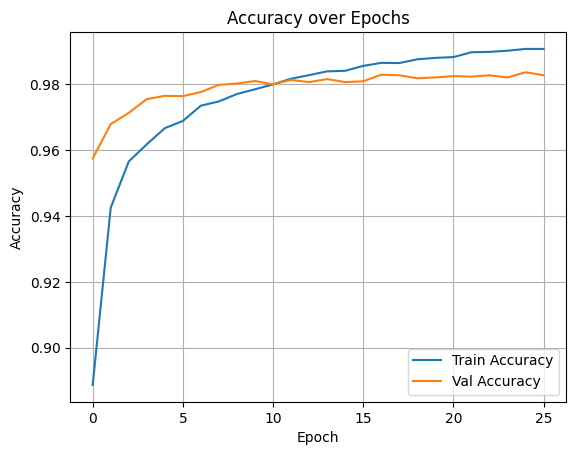

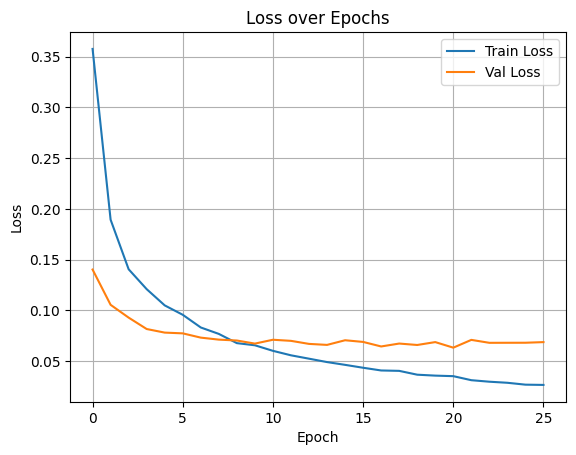

In [18]:
import matplotlib.pyplot as plt

plt.plot(history_final.history['accuracy'], label='Train Accuracy')
plt.plot(history_final.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history_final.history['loss'], label='Train Loss')
plt.plot(history_final.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


Se puede ver en accuracy que esta sigue aumentando aunque aumente la de entrenamiento. Esto indica que no existe overfitting y que el modelo generaliza bien. También la loss reduce mucho hasta que más o menos se vuelve constante a partir de la epoch 15, que va subiendo y bajando pero rondando los mismo valores.

In [19]:
test_loss, test_accuracy = model_final.evaluate(X_test, test_labels, verbose=0)
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')
print(f'Test Loss: {test_loss:.4f}')

Test Accuracy: 98.28%
Test Loss: 0.0568


Con los datos de test los resultados son aún más sorprendentes, con una loss inferior al 6%.
Son resultados muy buenos teniendo en cuenta que ya son los datos de test.


Se puede dar la actividad como concluida habiendo conseguido unos muy buenos resultados.